# IMPORTS

In [1]:
import numpy as np
import scipy
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import scipy.stats as stats
import warnings
import seaborn as sns
from pathlib import Path
from datetime import datetime
from windrose import WindroseAxes

# diive 
import importlib.metadata
version_diive = importlib.metadata.version("diive")
print(f"diive version: v{version_diive}")
from diive.core.dfun.stats import sstats  # Time series stats
from diive.core.io.files import save_parquet, load_parquet
from diive.core.plotting.timeseries import TimeSeries  # For simple (interactive) time series plotting
from diive.core.plotting.heatmap_datetime import HeatmapDateTime, HeatmapYearMonth

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)

# Matplotlib defaults
plt.rcParams["figure.autolayout"] = True
plt.rcParams["figure.figsize"] = (10, 4)

diive version: v0.89.0


# LOAD DATA

In [2]:
FILEPATH = r"..\\60_USTAR_FILTERING\\62.1_FLUXES_L3.3_NEE_LE_H_FN2O_FCH4_REDDYPROC.parquet"
data_original = load_parquet(filepath=FILEPATH)
maindf = data_original.copy()

maindf

Loaded .parquet file ..\\60_USTAR_FILTERING\\62.1_FLUXES_L3.3_NEE_LE_H_FN2O_FCH4_REDDYPROC.parquet (0.655 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


,AIR_CP,AIR_DENSITY,AIR_MV,AIR_RHO_CP,AOA_METHOD,AXES_ROTATION_METHOD,BADM_HEIGHTC,BADM_INSTPAIR_EASTWARD_SEP_GA_CH4,BADM_INSTPAIR_EASTWARD_SEP_GA_CO2,BADM_INSTPAIR_EASTWARD_SEP_GA_H2O,BADM_INSTPAIR_EASTWARD_SEP_GA_N2O,BADM_INSTPAIR_HEIGHT_SEP_GA_CH4,BADM_INSTPAIR_HEIGHT_SEP_GA_CO2,BADM_INSTPAIR_HEIGHT_SEP_GA_H2O,BADM_INSTPAIR_HEIGHT_SEP_GA_N2O,...,FLAG_L3.3_CUT_50_FN2O_L3.2_QCF0_USTAR_TEST,FN2O_L3.3_CUT_84_QCF0,FLAG_L3.3_CUT_84_FN2O_L3.2_QCF0_USTAR_TEST,FCH4_L3.3_CUT_16_QCF,FLAG_L3.3_CUT_16_FCH4_L3.2_QCF_USTAR_TEST,FCH4_L3.3_CUT_50_QCF,FLAG_L3.3_CUT_50_FCH4_L3.2_QCF_USTAR_TEST,FCH4_L3.3_CUT_84_QCF,FLAG_L3.3_CUT_84_FCH4_L3.2_QCF_USTAR_TEST,FCH4_L3.3_CUT_16_QCF0,FLAG_L3.3_CUT_16_FCH4_L3.2_QCF0_USTAR_TEST,FCH4_L3.3_CUT_50_QCF0,FLAG_L3.3_CUT_50_FCH4_L3.2_QCF0_USTAR_TEST,FCH4_L3.3_CUT_84_QCF0,FLAG_L3.3_CUT_84_FCH4_L3.2_QCF0_USTAR_TEST
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-07 15:45:00,1009.65,1.18057,0.024459,1191.96,0.0,1.0,0.5,-4.5,NaN,NaN,-4.5,-3.0,NaN,NaN,-3.0,...,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0
2023-11-07 16:15:00,1009.74,1.18107,0.024448,1192.57,0.0,1.0,0.5,-4.5,NaN,NaN,-4.5,-3.0,NaN,NaN,-3.0,...,0.0,0.324973,0.0,-4.360399,0.0,-4.360399,0.0,-4.360399,0.0,NaN,0.0,NaN,0.0,NaN,0.0
2023-11-07 16:45:00,1009.93,1.18176,0.024430,1193.50,0.0,1.0,0.5,-4.5,NaN,NaN,-4.5,-3.0,NaN,NaN,-3.0,...,0.0,0.053551,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0
2023-11-07 17:15:00,1009.97,1.18428,0.024377,1196.09,0.0,1.0,0.5,-4.5,NaN,NaN,-4.5,-3.0,NaN,NaN,-3.0,...,0.0,0.339963,0.0,2.488800,0.0,2.488800,0.0,2.488800,0.0,2.488800,0.0,2.488800,0.0,2.488800,0.0
2023-11-07 17:45:00,1010.06,1.18448,0.024372,1196.40,0.0,1.0,0.5,-4.5,NaN,NaN,-4.5,-3.0,NaN,NaN,-3.0,...,0.0,-0.983566,0.0,-9.177059,0.0,-9.177059,0.0,-9.177059,0.0,-9.177059,0.0,-9.177059,0.0,-9.177059,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 22:45:00,1014.01,1.14117,0.025232,1157.16,0.0,1.0,0.5,-4.5,2.0,2.0,-4.5,-3.0,-2.5,-2.5,-3.0,...,0.0,-0.069384,0.0,2.160966,0.0,2.160966,0.0,2.160966,0.0,2.160966,0.0,2.160966,0.0,2.160966,0.0
2025-06-04 23:15:00,1014.04,1.14156,0.025222,1157.59,0.0,1.0,0.5,-4.5,2.0,2.0,-4.5,-3.0,-2.5,-2.5,-3.0,...,0.0,-0.288296,0.0,-1.904577,0.0,-1.904577,0.0,-1.904577,0.0,NaN,0.0,NaN,0.0,NaN,0.0
2025-06-04 23:45:00,1013.47,1.14369,0.025185,1159.10,0.0,1.0,0.5,-4.5,2.0,2.0,-4.5,-3.0,-2.5,-2.5,-3.0,...,0.0,0.220511,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0


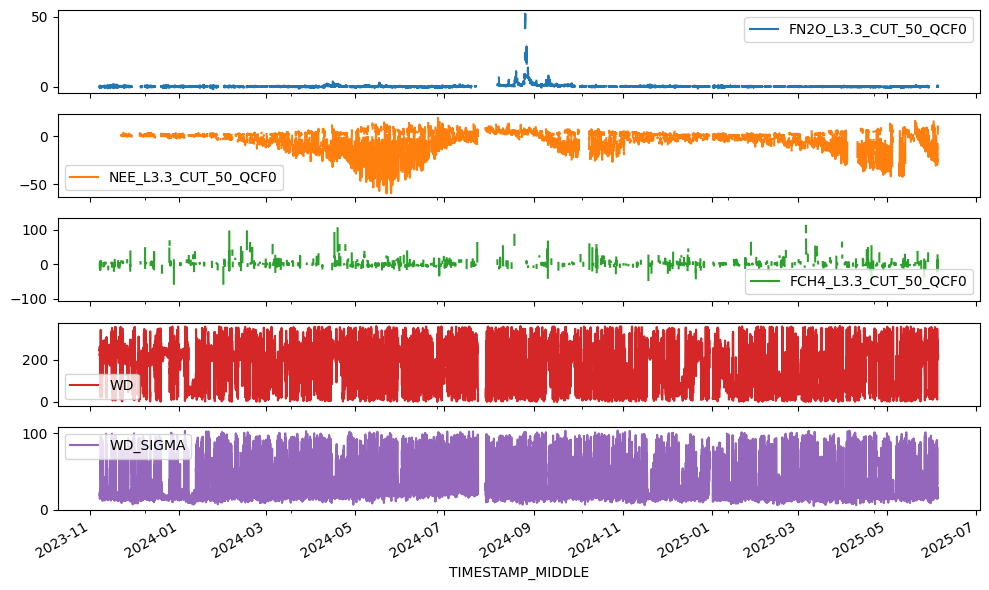

In [3]:
# Select fluxes
FLUXES = ['FN2O_L3.3_CUT_50_QCF0', 'NEE_L3.3_CUT_50_QCF0', 'FCH4_L3.3_CUT_50_QCF0']
WIND = ['WD', 'WD_SIGMA']
# Plot time series 
ax = maindf[FLUXES + WIND].plot(subplots=True, figsize=(10, 6), x_compat=True)
plt.show()

# WIND ROSES

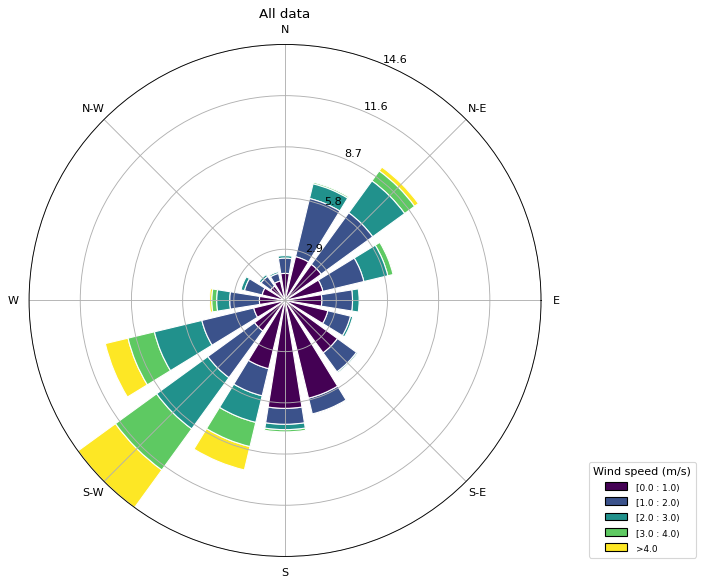

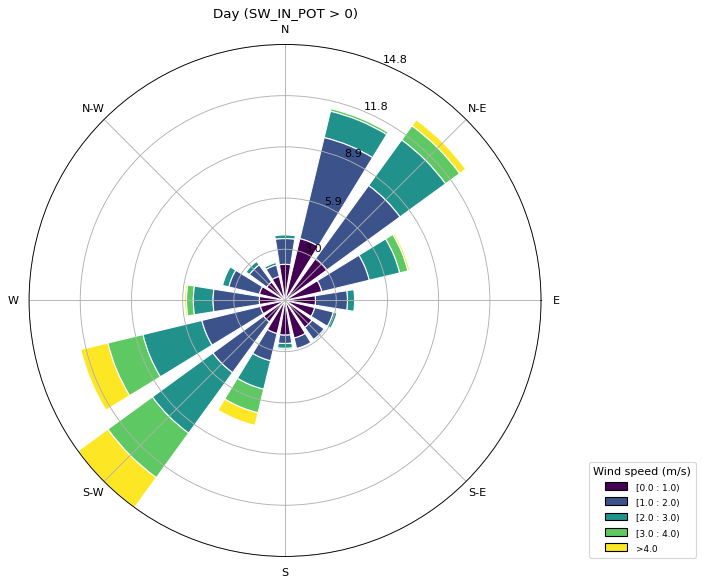

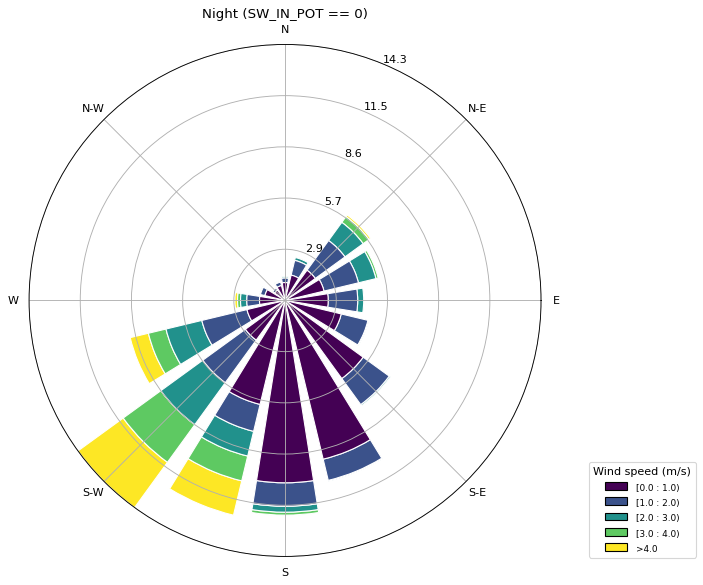

In [4]:
# Classify day/night
df = maindf.copy()
df["period"] = df["SW_IN_POT"].apply(lambda x: "Day" if x > 0 else "Night")

# Function to plot windrose
def plot_windrose(data, title):
    ax = WindroseAxes.from_ax()
    ax.bar(
        data["WD"], data["WS"],
        normed=True, opening=0.8, edgecolor="white",
        bins=[0,1,2,3,4],
        cmap=plt.cm.viridis
    )
    ax.set_title(title, fontsize=12)
    ax.set_legend(title="Wind speed (m/s)", loc="lower right", bbox_to_anchor=(1.3, 0))
    return ax

# --- Full data windrose ---
plot_windrose(df, "All data")

# --- Daytime windrose ---
plot_windrose(df[df["period"]=="Day"], "Day (SW_IN_POT > 0)")

# --- Nighttime windrose ---
plot_windrose(df[df["period"]=="Night"], "Night (SW_IN_POT == 0)")

plt.show()


# SPLIT INTO PARCELS

We assume the division line lies between 87° and 267°. A symmetric buffer is used to avoid ambiguous assignment.

FN2O_L3.3_CUT_50_QCF0: 0.00% lost to buffer (0.0°), 10.86% uncertain
NEE_L3.3_CUT_50_QCF0: 0.00% lost to buffer (0.0°), 11.82% uncertain
FCH4_L3.3_CUT_50_QCF0: 0.00% lost to buffer (0.0°), 11.63% uncertain


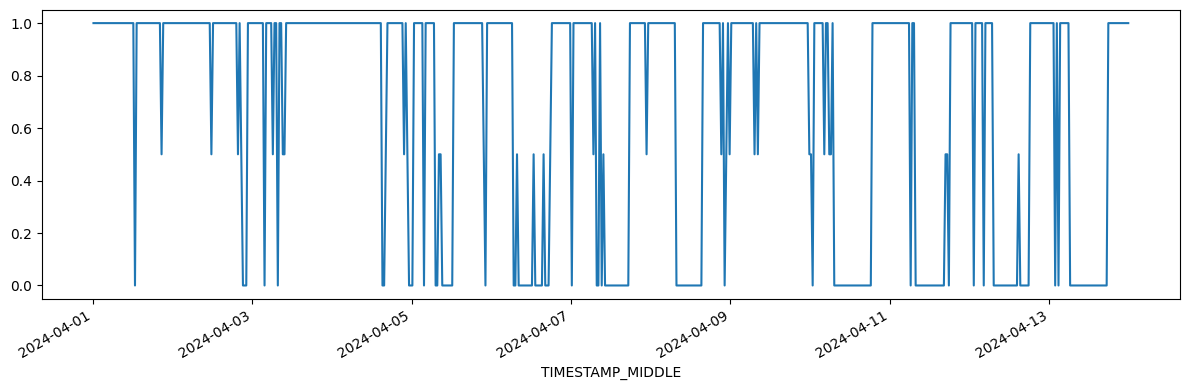

In [ ]:
wd  = maindf['WD']
sig = maindf['WD_SIGMA']
buffer = 0.0  # degrees; set to 0 if you don't want a center buffer

# A = [0,87) ∪ (267,360]; B = (87,267)
lower_angle = 87
upper_angle = 180.0 + lower_angle  # 267
# Only contained with confidence interval of WD
# interval edges (handle wrap)
factor = 0.5  # how many sigma to use for the interval
# interval edges (wrapped to [0, 360) )
lo = (wd - (sig * factor)) % 360
hi = (wd + (sig * factor)) % 360
wraps = lo > hi
# A sector = (0,87) ∪ (267,360)
A_full = (
    ((~wraps) & (hi < lower_angle)) |     # fully in (0,87)
    ((~wraps) & (lo > upper_angle)) |     # fully in (267,360)
    (wraps    & (hi < lower_angle)  & (lo > upper_angle))       # both sides within A
)
# B sector = (87,267) — cannot wrap
B_full = ((~wraps) & (lo > lower_angle) & (hi < upper_angle))

# SHRUNK windows (for classification with buffer) 
# A: below (87 - buffer) OR above (267 + buffer)
A_shrunk = (wd < (lower_angle - buffer)) | (wd > (upper_angle + buffer))
# B: strictly between, away from both boundaries by 'buffer'
B_shrunk = (wd > (lower_angle + buffer)) & (wd < (upper_angle - buffer))
# buffer zone: close to either treatment line
buffer_mask = (
    ((wd >= (lower_angle - buffer)) & (wd <= (lower_angle + buffer))) |
    ((wd >= (upper_angle - buffer)) & (wd <= (upper_angle + buffer)))
) & wd.notna()

# Define certainty logic
A_certain   = A_shrunk & A_full
A_uncertain = A_shrunk & ~A_full

B_certain   = B_shrunk & B_full
B_uncertain = B_shrunk & ~B_full

# Labels
maindf['parcel'] = np.nan
maindf['parcel_certainty'] = 'uncertain'

maindf.loc[buffer_mask,     'parcel'] = 'buffer'
maindf.loc[A_shrunk,   'parcel'] = 'A'
maindf.loc[B_shrunk,   'parcel'] = 'B'

maindf.loc[A_certain | B_certain,   'parcel_certainty'] = 'certain'
maindf.loc[A_uncertain | B_uncertain, 'parcel_certainty'] = 'uncertain'
maindf.loc[buffer_mask, 'parcel_certainty'] = 'buffer'

# Define a trt variable consisting of 0 for A, 1 for B and 0.5 for uncertain or buffer
maindf['trt'] = 0.5
maindf.loc[A_shrunk,   'trt'] = 0
maindf.loc[buffer_mask,     'trt'] = 0.5
maindf.loc[A_uncertain | B_uncertain, 'trt'] = 0.5
maindf.loc[B_shrunk,   'trt'] = 1

# Data loss to buffer and uncertainty assessment
for flux in FLUXES:
    total_count = maindf[flux].notna().sum()
    buffer_count = maindf.loc[maindf['parcel'] == 'buffer', flux].notna().sum()
    uncertain_count = maindf.loc[maindf['parcel_certainty'] == 'uncertain', flux].notna().sum()
    perc_loss_buffer   = buffer_count   / total_count * 100 if total_count else np.nan
    perc_loss_uncertain = uncertain_count / total_count * 100 if total_count else np.nan
    print(f"{flux}: {perc_loss_buffer:.2f}% lost to buffer ({buffer}°), "
          f"{perc_loss_uncertain:.2f}% uncertain")

maindf

maindf['trt']['2024-04-01':'2024-04-13'].plot(x_compat=True, figsize=(12,4));

# CHECK DAY-NIGHT DISTRIBUTION

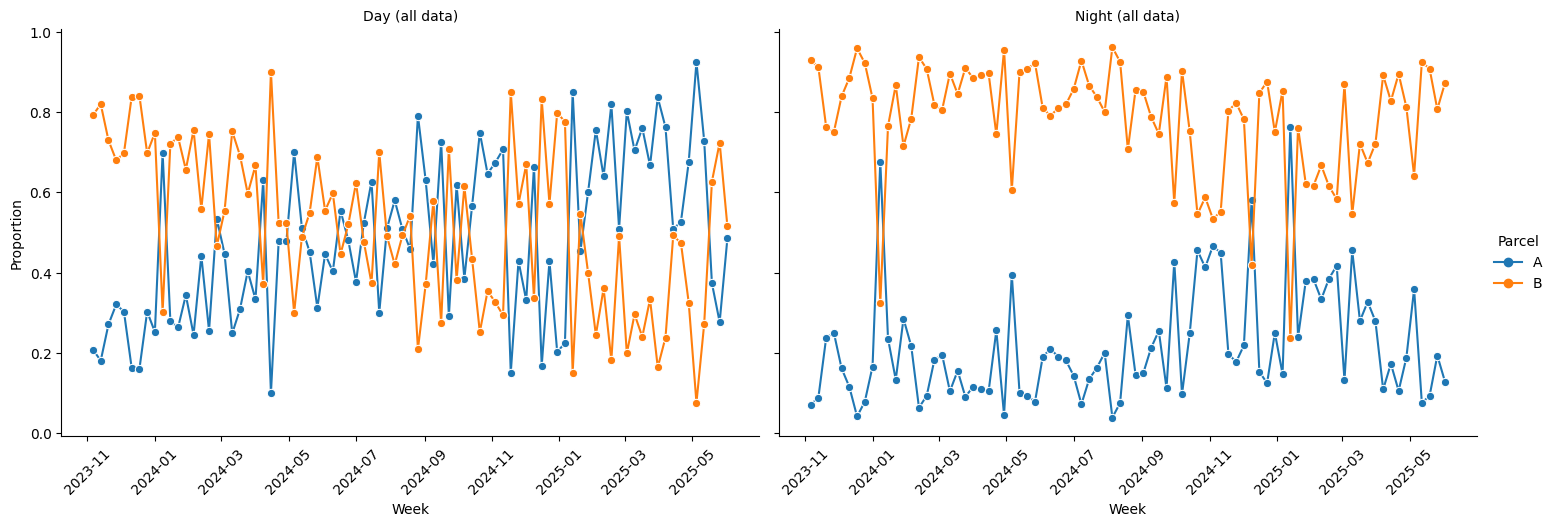

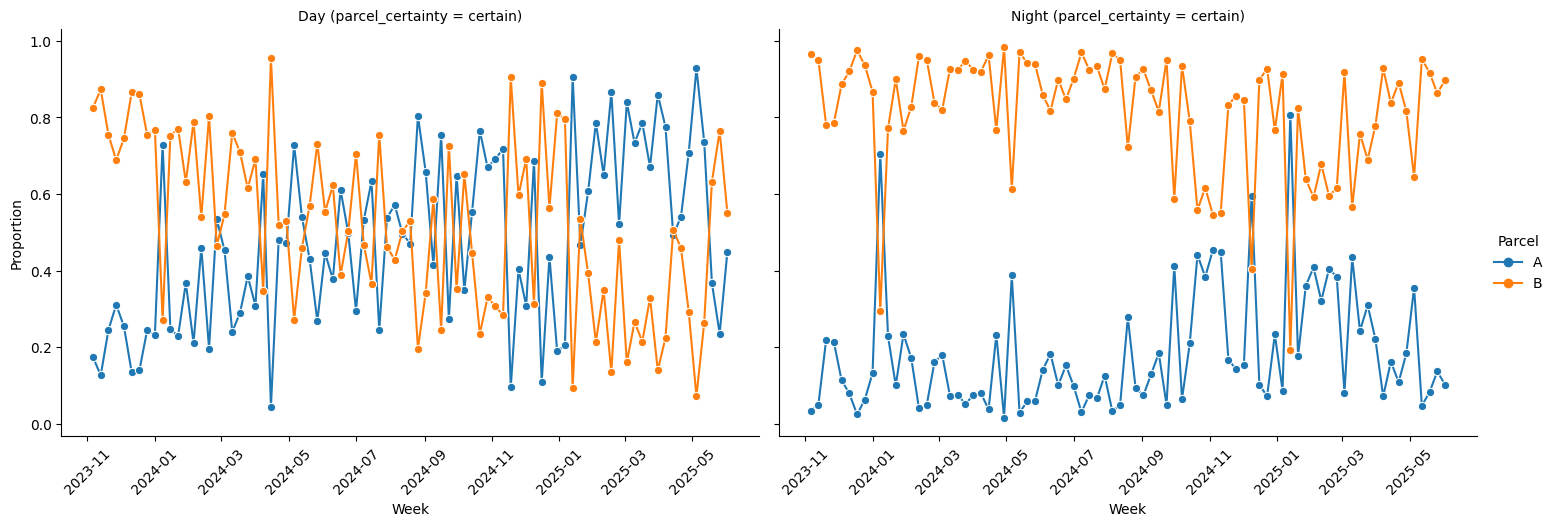

In [6]:
def plot_weekly_distribution(df, title_suffix=""):
    # Make sure timestamp is datetime
    df["TIMESTAMP_MIDDLE"] = pd.to_datetime(df["TIMESTAMP_MIDDLE"])

    # Extract year-week
    df["week_start"] = df["TIMESTAMP_MIDDLE"].dt.to_period("W").apply(lambda r: r.start_time)

    # Classify day vs night
    df["period"] = df["SW_IN_POT"].apply(lambda x: "Day" if x > 0 else "Night")

    # Count
    counts = (
        df.groupby(["week_start","period","parcel"])
          .size().reset_index(name="n")
    )

    # Normalize to proportions
    counts["prop"] = counts.groupby(["week_start","period"])["n"].transform(lambda x: x / x.sum())
    counts = counts.sort_values("week_start")

    # Plot
    g = sns.relplot(
        data=counts,
        x="week_start", y="prop", hue="parcel",
        col="period", kind="line",
        height=5, aspect=1.5,
        marker="o"
    )

    g.set_axis_labels("Week", "Proportion")
    g.set_titles("{col_name} " + title_suffix)
    g._legend.set_title("Parcel")
    for ax in g.axes.flat:
        ax.tick_params(axis="x", rotation=45)

    plt.show()


# Full dataset
plot_weekly_distribution(maindf.reset_index().copy(), title_suffix="(all data)")

# Subset: parcel_certainty == 'certain'
df_certain = maindf[maindf['parcel_certainty']=='certain'].reset_index().copy()
plot_weekly_distribution(df_certain, title_suffix="(parcel_certainty = certain)")


# PLOTS

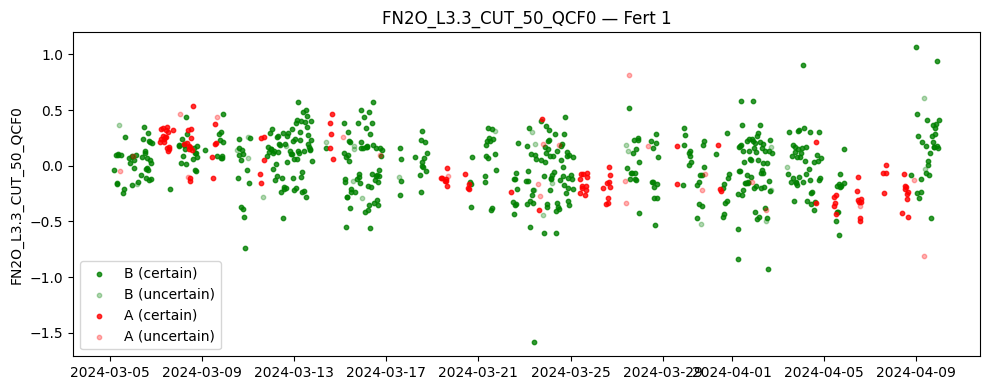

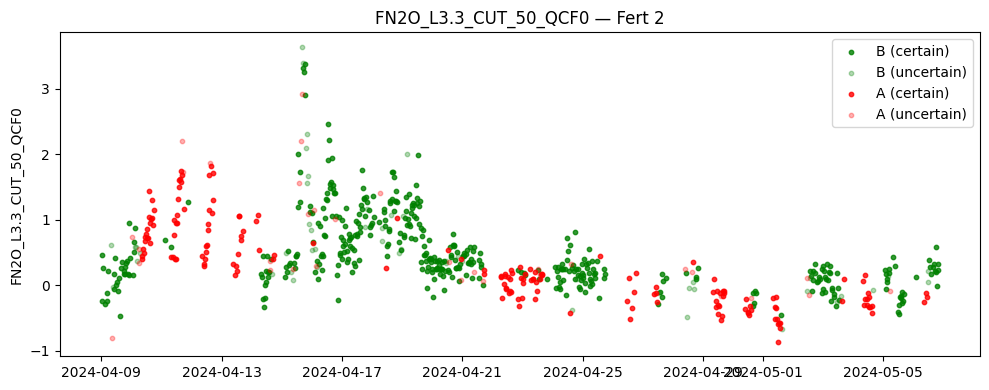

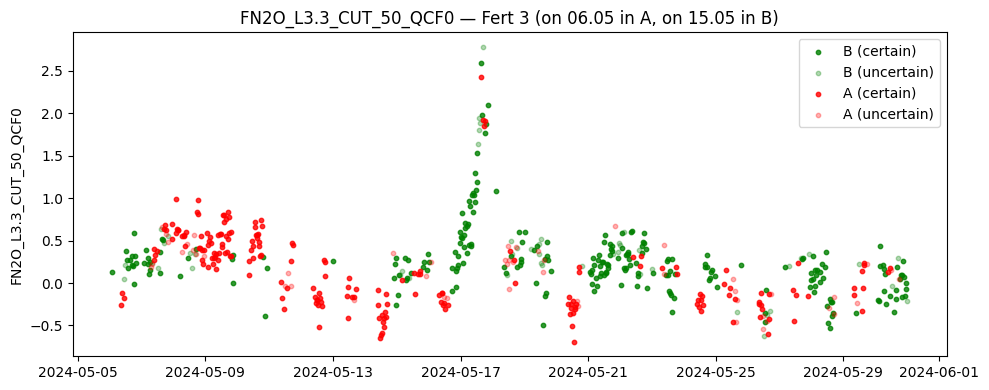

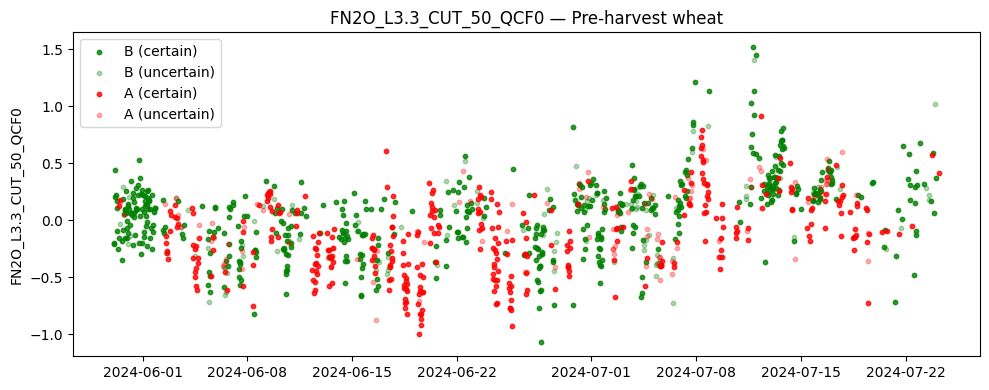

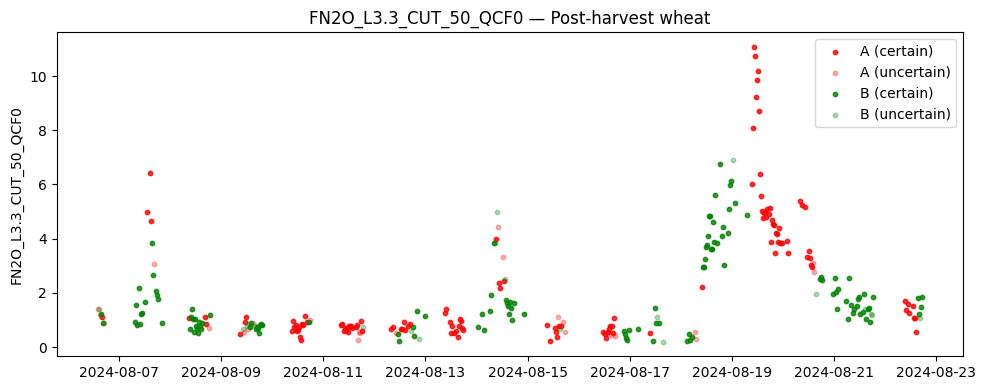

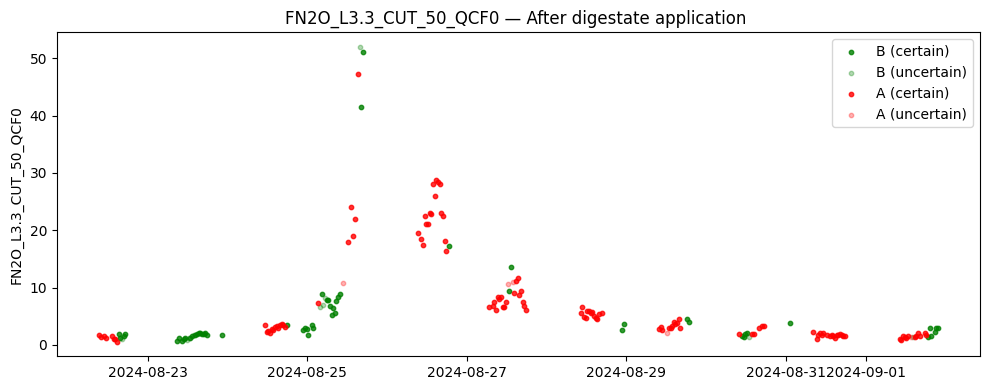

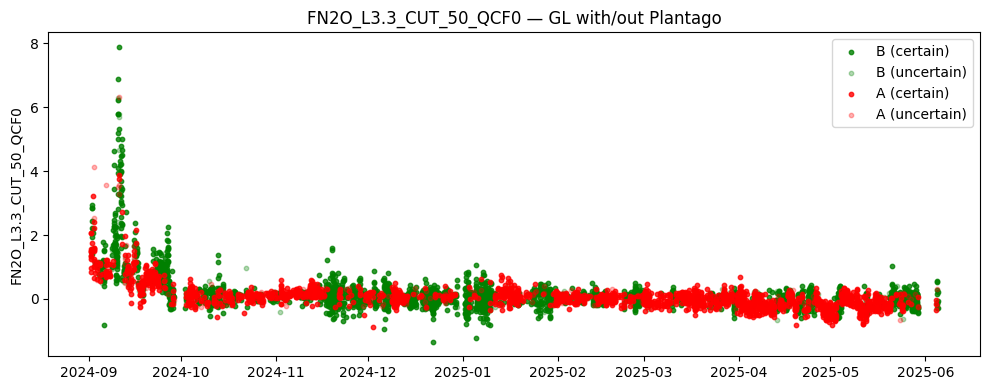

In [7]:
# --- Period definitions ---
periods = [
    ("Fert 1",  "2024-03-05", "2024-04-09"),
    ("Fert 2",  "2024-04-09", "2024-05-06"),
    ("Fert 3 (on 06.05 in A, on 15.05 in B)", "2024-05-06", "2024-05-30"),
    ("Pre-harvest wheat", "2024-05-30", "2024-07-25"),
    ("Post-harvest wheat", "2024-07-25", "2024-08-22"),
    ("After digestate application ", "2024-08-22", "2024-09-01"),
    ("GL with/out Plantago", '2024-09-01', '2025-06-05')
]

flux = FLUXES[0]
fixed_colors = {'A': 'red', 'B': 'green', 'buffer': 'gray'}

for label, start, end in periods:
    indat = maindf.loc[start:end].copy()
    if indat.empty:
        print(f"No data for period: {label} ({start} to {end})")
        continue

    plt.figure(figsize=(10, 4))
    for parcel in indat['parcel'].dropna().unique():
        for cert, alpha in [('certain', 0.8), ('uncertain', 0.3)]:
            sub = indat[(indat['parcel'] == parcel) &
                        (indat['parcel_certainty'] == cert)]
            if sub.empty or (flux not in sub.columns):
                continue
            plt.scatter(
                sub.index, sub[flux],
                label=f"{parcel} ({cert})",
                s=10,
                alpha=alpha,
                color=fixed_colors.get(parcel, 'black'),
            )

    plt.title(f"{flux} — {label}")
    plt.xlabel('')
    plt.ylabel(flux)
    plt.legend()
    plt.tight_layout()
    plt.show()

# PRELIMINARY COMPARISON TRT

In [8]:
GAS    = 'FN2O'
IN_COL = f'{GAS}_L3.3_CUT_50_QCF'
TOL    = pd.Timedelta('3h')  

def contiguous_pairs(df_long, certain_only=False, tol=TOL):
    # Select data
    d = df_long if not certain_only else df_long[df_long['parcel_certainty'] == 'certain']
    # keep only valid rows so "next" truly means next valid record
    d = d[d['parcel'].isin(['A','B'])].dropna(subset=[IN_COL, 'parcel']).sort_index()
    # Get adjacent rows
    d['t_next']      = pd.Series(d.index, index=d.index).shift(-1)
    d['parcel_next'] = d['parcel'].shift(-1)
    d['val_next']    = d[IN_COL].shift(-1)
    # Keep only rows where parcel changes
    b = d[d['parcel'] != d['parcel_next']].copy()
    # Calculate time difference
    b['dt'] = (b['t_next'] - b.index).abs()
    # Remove pairs exceeding tolerance
    b = b[b['dt'] <= tol]
    # Assign values to A and B
    b[f'{GAS}_A'] = np.where(b['parcel'] == 'A', b[IN_COL], b['val_next'])
    b[f'{GAS}_B'] = np.where(b['parcel'] == 'B', b[IN_COL], b['val_next'])
    b['t_A']      = np.where(b['parcel'] == 'A', b.index,  b['t_next'])
    b['t_B']      = np.where(b['parcel'] == 'B', b.index,  b['t_next'])
    # Drop rows with no valid pair (any side missing)
    b = b.dropna(subset=[f'{GAS}_A', f'{GAS}_B', 't_A', 't_B'])
    # Calculate mid-time
    b['t_mid'] = b[['t_A','t_B']].min(axis=1) + (b['dt'] / 2)
    return b.set_index('t_mid')[[ 't_A','t_B', f'{GAS}_A', f'{GAS}_B', 'dt' ]].sort_index()

# build
df      = maindf[[IN_COL, 'parcel', 'parcel_certainty']].sort_index()
pairs_all     = contiguous_pairs(df, certain_only=False, tol=TOL)
pairs_certain = contiguous_pairs(df, certain_only=True, tol=TOL)

## Plots

### Paired plot

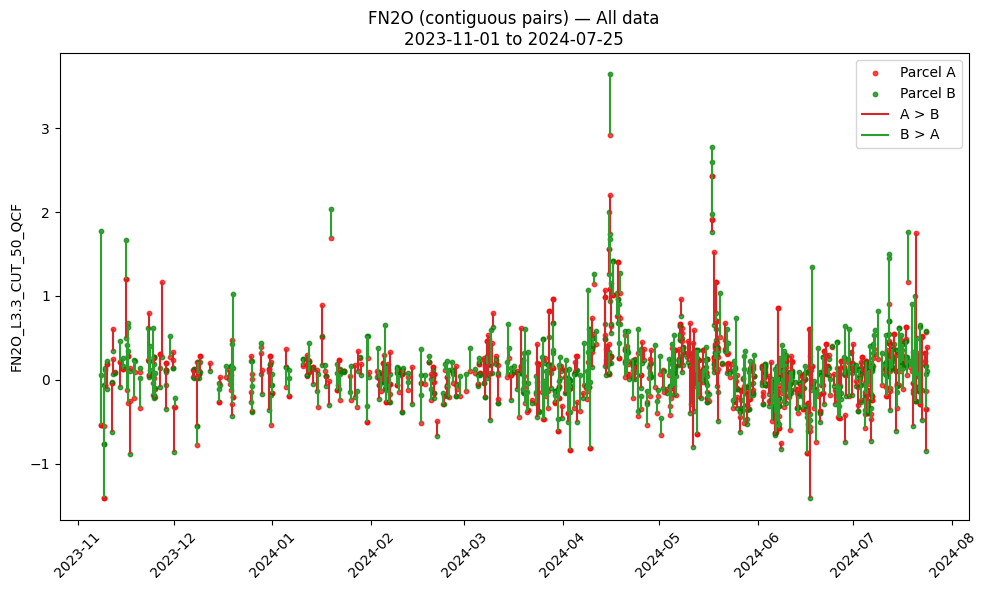

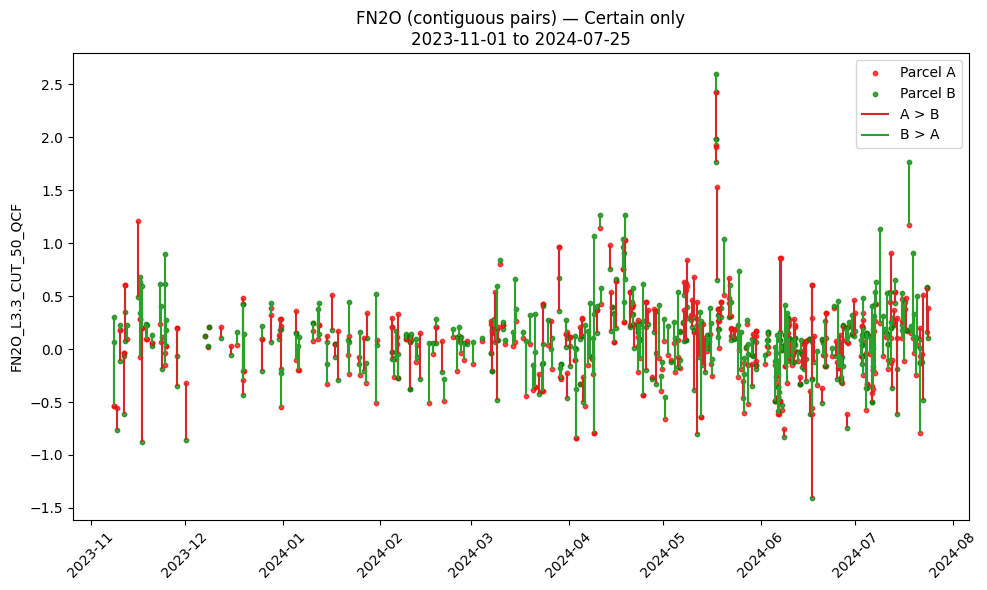

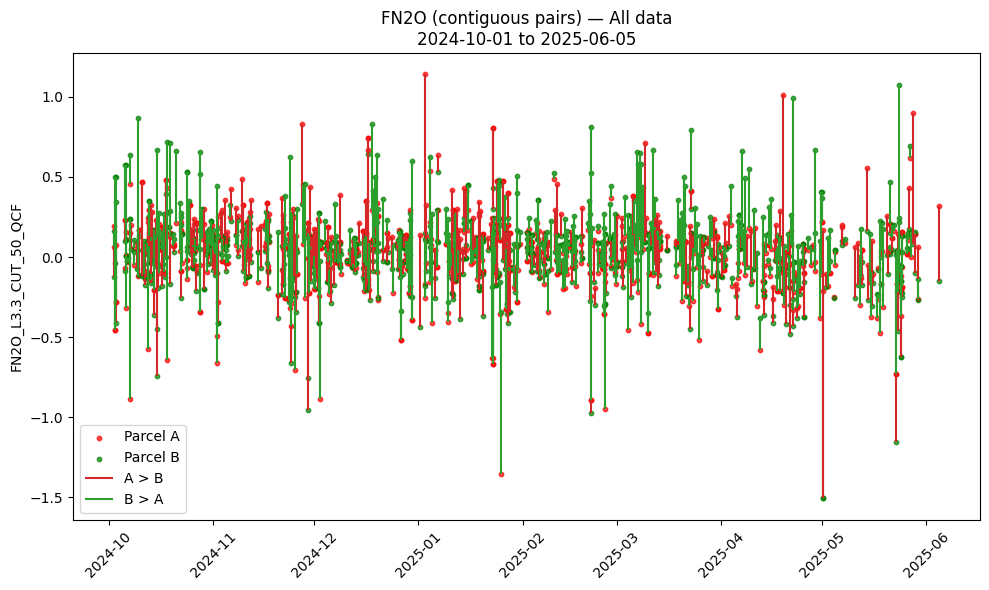

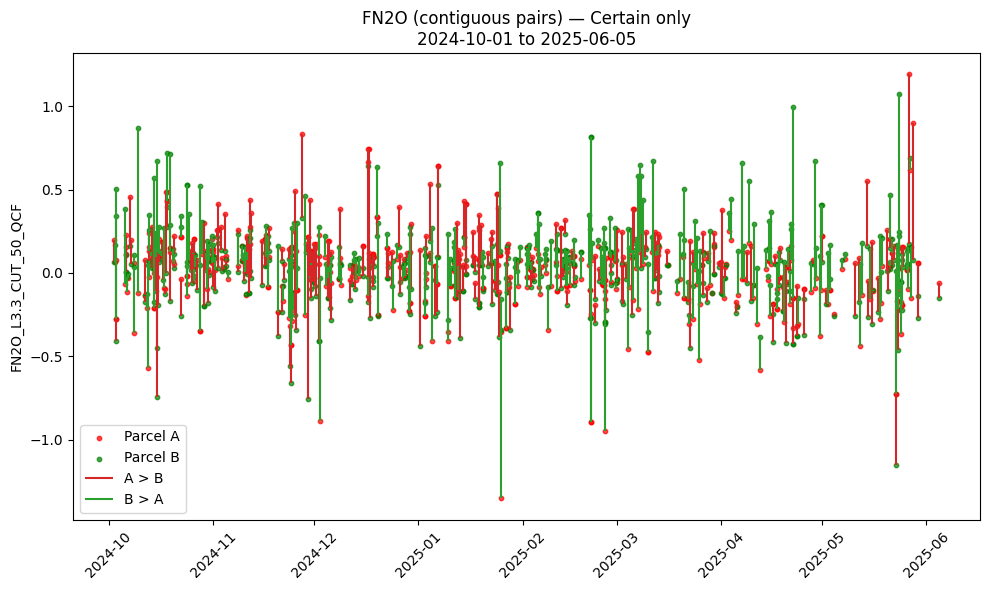

In [9]:
# Paired plot with points and vertical lines
def plot_pairs(pairs, start, end, title):
    sub = pairs.loc[start:end]
    a, b, x = sub[f'{GAS}_A'], sub[f'{GAS}_B'], sub.index
    plt.figure(figsize=(10,6))
    plt.scatter(x, a, label='Parcel A', s=10, alpha=0.7, c='red')
    plt.scatter(x, b, label='Parcel B', s=10, alpha=0.7, c='green')
    plt.vlines(x[a>b], ymin=b[a>b], ymax=a[a>b], linewidth=1.5, label='A > B', color='tab:red')
    plt.vlines(x[b>a], ymin=a[b>a], ymax=b[b>a], linewidth=1.5, label='B > A', color='tab:green')
    plt.title(f"{GAS} (contiguous pairs) — {title}\n{start} to {end}")
    plt.ylabel(IN_COL); plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()

for s,e in [("2023-11-01","2024-07-25"), ("2024-10-01","2025-06-05")]:
    plot_pairs(pairs_all, s, e, "All data")
    plot_pairs(pairs_certain, s, e, "Certain only")

### Resampled plot

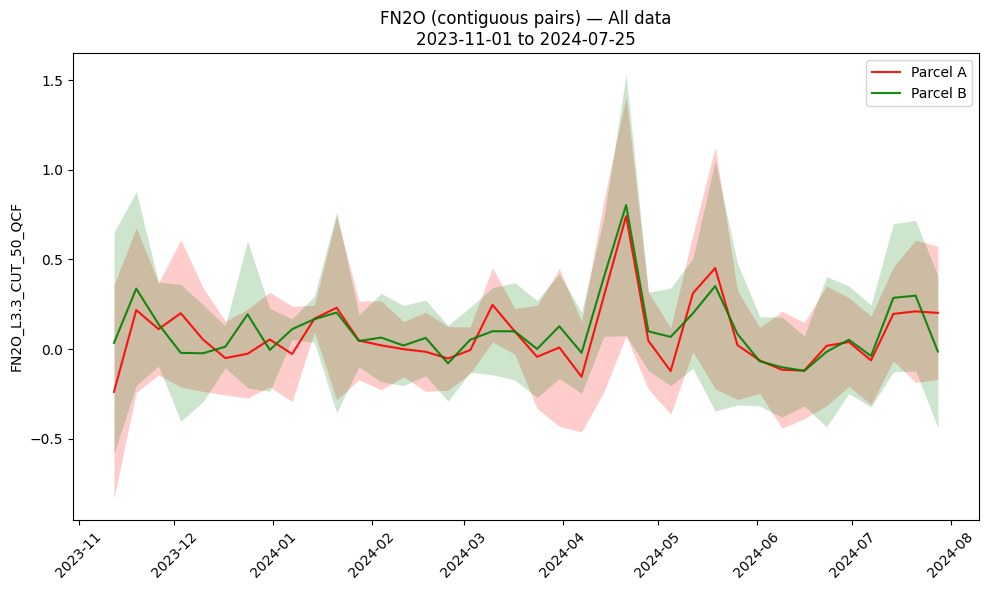

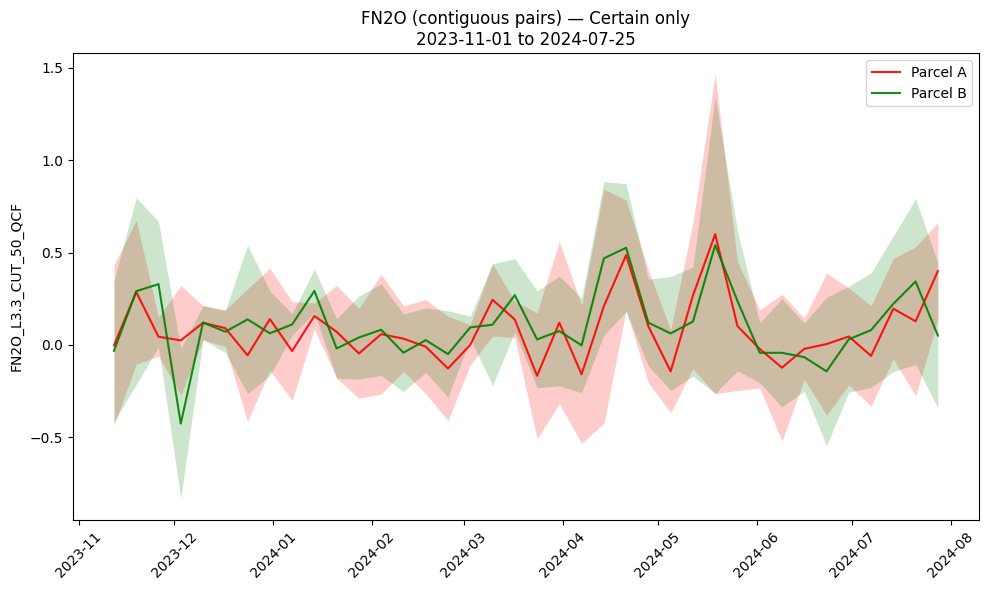

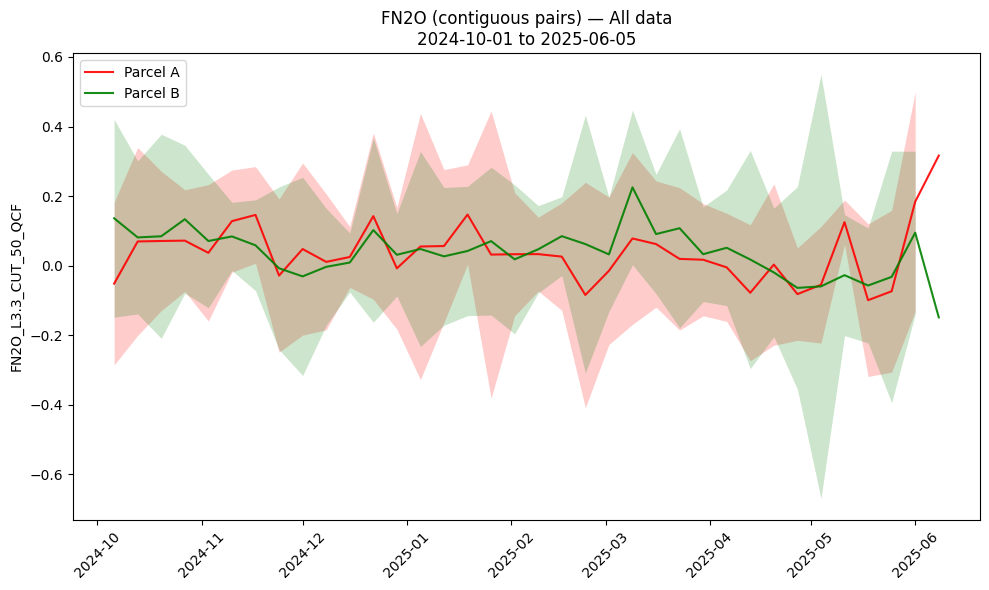

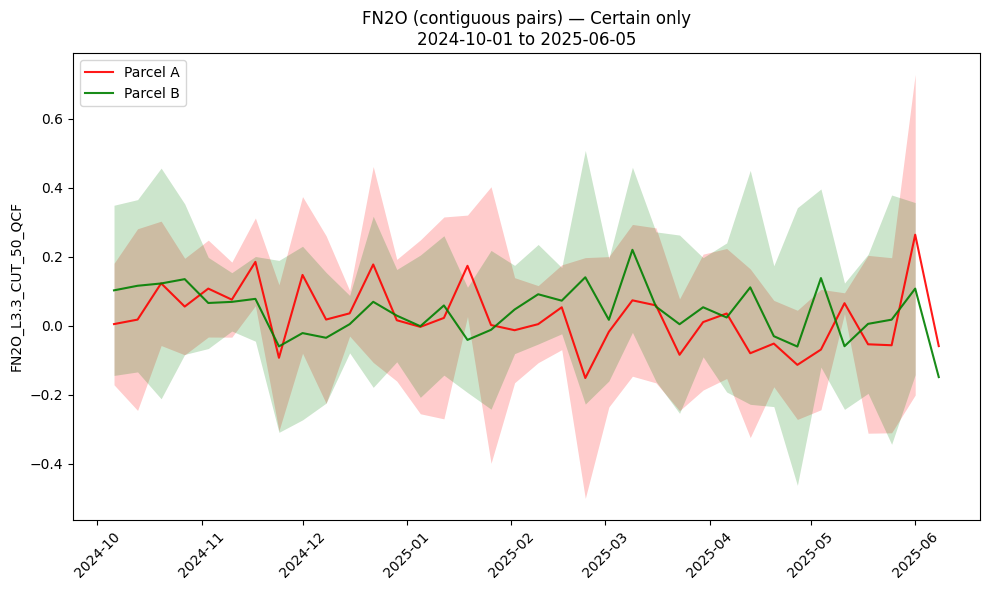

In [10]:
def plot_subsampled(pairs, start, end, title, res='W'):
    sub = pairs.loc[start:end]
    # weekly mean & std in one go
    resampled = sub.resample(res).agg({
        f'{GAS}_A': ['mean', 'std'],
        f'{GAS}_B': ['mean', 'std'],
    })

    a_mean = resampled[(f'{GAS}_A', 'mean')]
    a_std  = resampled[(f'{GAS}_A', 'std')]
    b_mean = resampled[(f'{GAS}_B', 'mean')]
    b_std  = resampled[(f'{GAS}_B', 'std')]

    x = resampled.index

    plt.figure(figsize=(10,6))
    # lines
    plt.plot(x, a_mean, label='Parcel A', alpha=0.9, c='red')
    plt.plot(x, b_mean, label='Parcel B', alpha=0.9, c='green')
    # ±1 SD shading
    plt.fill_between(x, a_mean - a_std, a_mean + a_std, alpha=0.2, linewidth=0, color='red')
    plt.fill_between(x, b_mean - b_std, b_mean + b_std, alpha=0.2, linewidth=0, color='green')

    plt.title(f"{GAS} (contiguous pairs) — {title}\n{start} to {end}")
    plt.ylabel(IN_COL)
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

for s, e in [("2023-11-01","2024-07-25"), ("2024-10-01","2025-06-05")]:
    plot_subsampled(pairs_all, s, e, "All data", res='W')
    plot_subsampled(pairs_certain, s, e, "Certain only", res='W')


### Cumulative plot

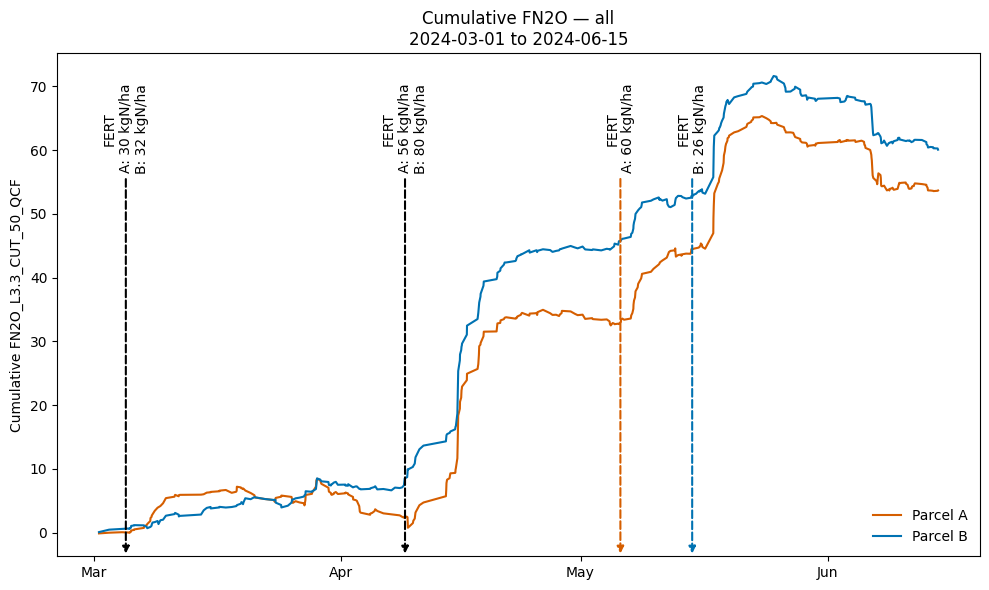

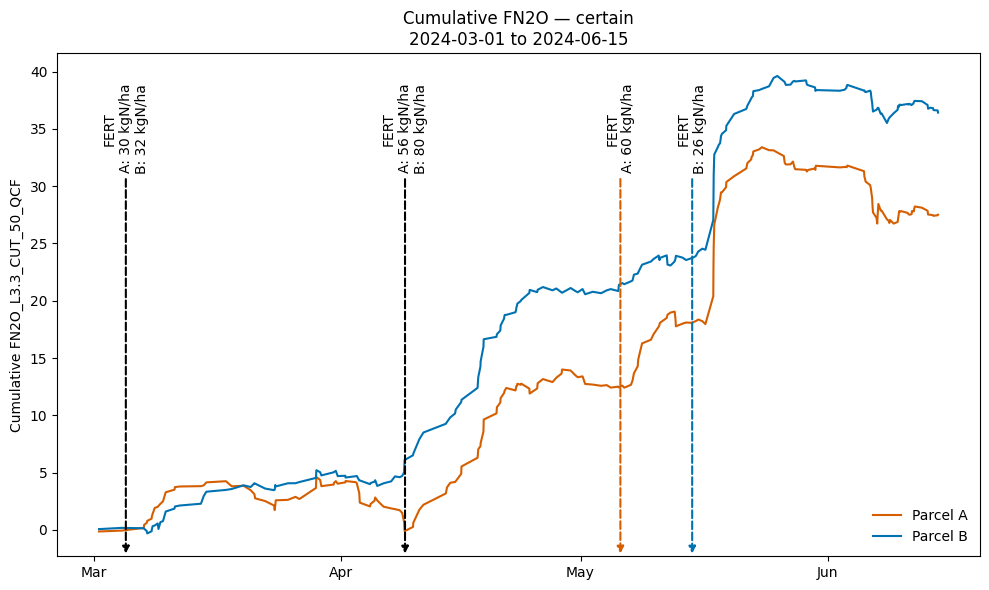

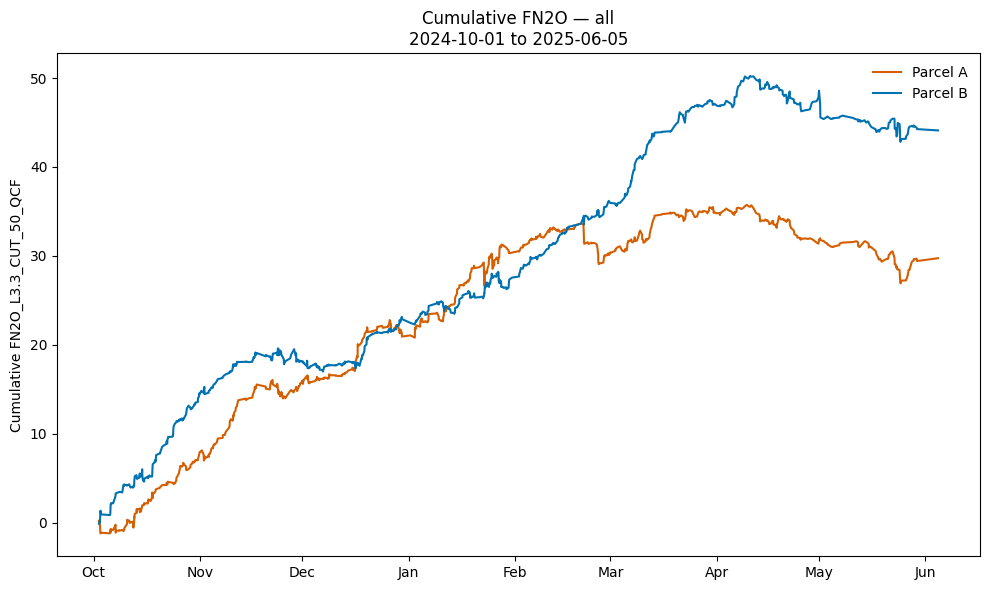

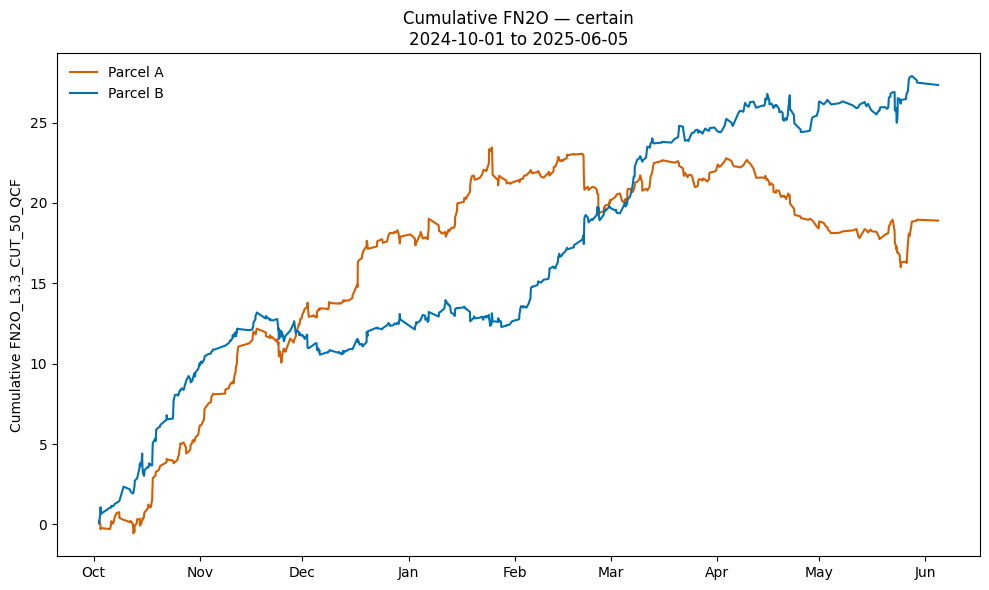

In [11]:
periods = [
    ("2024-03-01", "2024-06-15"),  # Wheat
    ("2024-10-01", "2025-06-05"),  # Grassland
]

# Define labels and colors for the management events
# Colors for the 2 parcels
COLORS = {'A': "#D55E00", 'B': "#0072B2"}
event_lines = [
    {'date': '2024-03-05', 'color': 'black', 'linestyle': '--', 'label': 'FERT\nA: 30 kgN/ha\nB: 32 kgN/ha'},
    {'date': '2024-04-09', 'color': 'black', 'linestyle': '--', 'label': 'FERT\nA: 56 kgN/ha\nB: 80 kgN/ha'},
    {'date': '2024-05-06', 'color': COLORS['A'], 'linestyle': '--', 'label': 'FERT\nA: 60 kgN/ha'},
    {'date': '2024-05-15', 'color': COLORS['B'], 'linestyle': '--', 'label': 'FERT\nB: 26 kgN/ha'}
]

for start, end in periods:
    start_ts = pd.to_datetime(start)
    end_ts   = pd.to_datetime(end)

    for df, title in [
        (pairs_all, "all"),
        (pairs_certain, "certain"),
    ]:
        # Subset
        subdf = df.loc[start_ts:end_ts].copy()

        # Cumulative (use subset index)
        cum_df = pd.DataFrame(index=subdf.index)
        cum_df[f'{GAS}_A'] = subdf[f'{GAS}_A'].cumsum()
        cum_df[f'{GAS}_B'] = subdf[f'{GAS}_B'].cumsum()

        # Plot
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.plot(cum_df.index, cum_df[f'{GAS}_A'], label='Parcel A', color=COLORS['A'])
        ax.plot(cum_df.index, cum_df[f'{GAS}_B'], label='Parcel B', color=COLORS['B'])

        # Annotate only events within the period
        for event in event_lines:
            event_date = pd.to_datetime(event['date'])
            if not (start_ts <= event_date <= end_ts):
                continue
            ax.annotate(
                text=event['label'],
                xy=(mdates.date2num(event_date), 0),
                xytext=(mdates.date2num(event_date), 0.85),
                xycoords=('data', 'axes fraction'),
                textcoords=('data', 'axes fraction'),
                ha='center', va='center',
                rotation=90, rotation_mode='anchor',
                color='black',
                arrowprops=dict(
                    arrowstyle='-|>',
                    color=event['color'],
                    linestyle=event['linestyle'],
                    lw=1.5
                ),
                annotation_clip=False
            )

        # X-axis formatting
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

        ax.set_title(f"Cumulative {GAS} — {title}\n{start} to {end}")
        ax.set_ylabel(f'Cumulative {IN_COL}')
        ax.legend(frameon=False)
        fig.tight_layout()
        fig.savefig(f'plots/Cumulative_{GAS}_{title}_from{start}_to{end}.png', dpi=300, bbox_inches='tight')
        plt.show()

# EXPORT

In [12]:
newcols = [c for c in maindf.columns if c not in data_original.columns]
print("NEW VARIABLES ADDED TO THE DATASET:")
for c in newcols:
    print(f"+ {c}")

NEW VARIABLES ADDED TO THE DATASET:
+ parcel
+ parcel_certainty
+ trt


In [13]:
filename = "71.1_FLUXES_L3.3_NEE_LE_H_FN2O_FCH4_REDDYPROC_PARCELS"
save_parquet(data=maindf, filename=filename)

Saved file 71.1_FLUXES_L3.3_NEE_LE_H_FN2O_FCH4_REDDYPROC_PARCELS.parquet (4.533 seconds).


'71.1_FLUXES_L3.3_NEE_LE_H_FN2O_FCH4_REDDYPROC_PARCELS.parquet'

# End of notebook

In [14]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2025-10-30 19:15:01
